In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unitaria as ut

np.set_printoptions(precision=3, suppress=True, threshold=100)

# Block Encoding the 1D Laplace Equation

This notebook provides a deep dive into constructing, correcting, and inverting the 1D discrete Laplace operator using our block encoding library.

## 1. Problem Setup and Constants

On the 1-dimensional domain $D = [0, 1]$ the Laplace equation with homogeneous boundary condition is given by
\begin{align*}
-\Delta u &= f && \text{in }D \\
u &= 0 && \text{on }\partial D
\end{align*}
We solve for the function $u \in H^1_0(D)$ given the right hand side $f \in L^2(D)$.
The weak form of this equation is
$$
a(u, v) = (v, f)_{L^2} \qquad\forall v \in H^1_0(D)
$$
where $a(u, v) = (\nabla u, \nabla v)_{L^2}$.

## 2. Discretizing the Laplace equation

To discretize the Laplace equation we choose a finite dimensional subspace of the function space $H^1$. We divide our domain $D$ into the intervals
$$ D = [x_0, x_1) \cup \dots \cup [x_{2^N-1}, x_{2^N}] $$
For our example we choose the refinement level as

In [2]:
N = 3

We now consider the basis of "hat functions", $\Lambda_1, \dots \Lambda_{2^N-1}$, which are continues, piecewise linear on the above intervals, and satisfy
$$
\Lambda_j(x_k) = \begin{cases} 1 & \text{if }j = k \\ 0 & \text{if }j \neq k \end{cases}.
$$
The discrete stiffness matrix $S$ in this basis is then given by
$$S_{jk} = a(\Lambda_j, \Lambda_k) = \begin{cases}
2^{N + 1} & \text{if } j = k \\
-2^N & \text{if } j = k-1 \lor j = k+1
\end{cases}
$$

## 3. Block encoding the stiffness matrix

To perform computations involving the stiffness matrix on a quantum computer, we need to construct a block encoding of $S$. This is where Unitaria comes in. (This tutorial does not require you to know what a block encoding is, but you can read about it at ... if you are interested.)

To efficiently block encode a matrix, we have to decompose it into simpler elements.
Here, we notice that $S$ has a tridiagonal structure
$$
S = 2^N\begin{bmatrix}
2 & 1 \\
1 & \ddots & \ddots \\
& \ddots&& 1 \\
&& 1 & 2
\end{bmatrix} = 2^N (2\operatorname{Id}_{2^N-1} - X - X^T) \qquad\text{where}\qquad
X = \begin{bmatrix}
0  \\
1 & \ddots \\
& \ddots& \\
&& 1 & 0
\end{bmatrix}.
$$

### The matrix $I$
The identity is easy to encode. Unitaria already contains code to do this construction.

In [3]:
Id = ut.Identity(dim=2**N - 1)

The variable `Id` now contains information about both the encoded operation, and the information -- quantum circuit, normaliation, and subspaces -- required for a block encoding. Let us have a quick look how to access this information. The circuit is accessed through the method `circuit`.

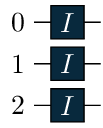

In [4]:
Id.circuit().draw()

To transform a vector by the identity means simply to do nothing, so it is encoded by a quantum circuit that just applies the identity gate to each qubit.

The number of this qubits in this circuit is $m = 3$, since the dimension $2^m = 8$ of the state space needs to be at least as large as the dimension of our matrix, which is $2^N-1 = 7$. This means the circuit by itself encodes the matrix $\operatorname{Id}_8$. To specify that only the 7 first rows and columns should be used, the block encoding has two attributes -- `I.subspace_in` and `I.subspace_out` -- that contain this information.

In [5]:
print(Id.subspace_in.enumerate_basis())
print(Id.subspace_out.enumerate_basis())

[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6]


Finally, the normalization -- being related to the spectral norm -- for this block encoding is 1.

In [6]:
Id.normalization

1

Of course, we can alsot just print out the encoded matrix.

In [7]:
print(Id.toarray())

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


### The matrix $X$

On the other hand, $X$ is a matrix with $1$s on its first subdiagonal. It maps the $j$-th basis vector to the $(j + 1)$-th basis vector. Thus it corresponds to the binary operation $|x\rangle \mapsto |x + 1\rangle$

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]]


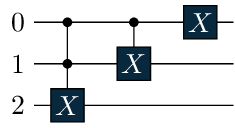

In [8]:
# Basic shift operator
X_periodic = ut.Increment(bits=N)
print(X_periodic.toarray())
X_periodic.circuit().draw()

Note, however, that this is not quite the matrix that we wanted. Specifically, the block encoding `X_periodic` implements the increment modulo $2^N$. The result of incrementing $2^N-1$ is then equal to $0$, leading to a $1$ in the upper-right corner of `X_periodic`. Still, this would allow us to define a block encoding for the **periodic** version of the stiffness matrix.

[[16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j]
 [-8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j]
 [-8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j]]


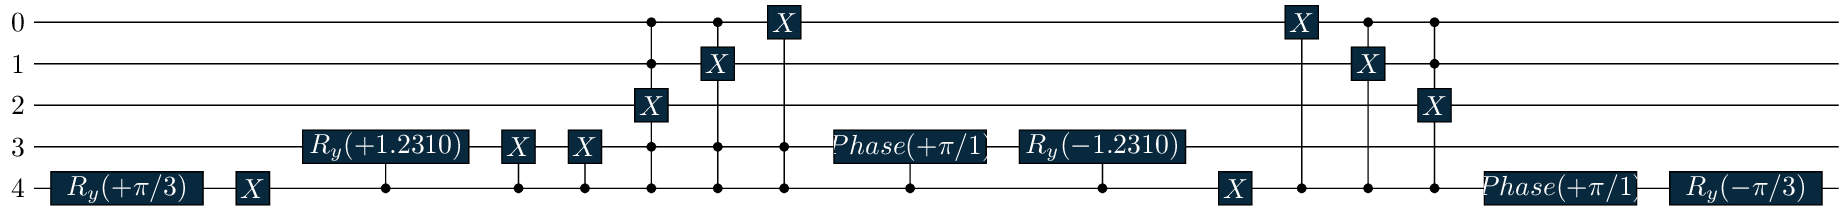

In [9]:
A_periodic = 2**N * (2 * ut.Identity(dim=2**N) - X_periodic - X_periodic.adjoint())
print(A_periodic.toarray())
A_periodic.circuit().draw()

## 3. Boundary Conditions and Projections

The `Increment` operator is cyclic (it "wraps" around from $2^n-1$ back to $0$). In a standard Laplace problem with Dirichlet boundary conditions, we don't want this wrap-around. This "wrapping" introduces unwanted $-1$ values at the corners of the matrix.

To fix this, we apply a **Projection**. We define a subspace that excludes the "wrap-around" state and project our operator onto it. For this, let us first specify the total space of the `Increment` block encoding.

In [10]:
total_space = X_periodic.subspace_out

The method `enumerate_basis` is for testing purposes, and tells us, which computational basis states are in the subspace.

In [11]:
total_space.enumerate_basis()

array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32)

We want to project our matrix to the first 7 rows and columns. For this we can use the method `Subspace.from_dim`.

In [12]:
boundary_subspace = ut.Subspace.from_dim(2**N - 1, bits=N)
print(f"dimension = {boundary_subspace.dimension}")
print(f"qubits = {boundary_subspace.total_qubits}")
boundary_subspace.enumerate_basis()

dimension = 7
qubits = 3


array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

With this we can create the projection matrix onto the first seven coordinates.

In [13]:
proj = ut.Projection(total_space, boundary_subspace)
proj.toarray()

array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j]])

We obtain `A` by applying the projection to both the rows and the columns.

In [14]:
A = proj @ A_periodic @ proj.adjoint()
A.toarray()

array([[16.+0.j, -8.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [-8.+0.j, 16.+0.j, -8.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -8.+0.j, 16.+0.j, -8.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j]])

### Sidenote: Internal representation of subspaces

In the present context, we know that `total_space` is the space of $N$ qubits, so we can equivalently write

In [15]:
total_space = ut.Subspace("#" * N)

The symbol `#` in the constructor of `ut.Subspace` here refers to a bit that can be either `0` or `1`. The other allowed symbol is `0`, which specifies that the corresponding bit has to be zero. This allows to write, for example, `ut.Subspace("##0")` for the subspace of $\mathbb{C}^{2^3}$, where the lowest bit is zero.

In [16]:
example_space = ut.Subspace("##0")
example_space.enumerate_basis()

array([0, 2, 4, 6], dtype=int32)

The `boundary_subspace` is slightly more complex than `total_space`, since it does not have a tensor structure. Concretely, we want **all** of the basis states where the highest bit is `0`, but only **some** of the states where the highest bit is `1`, namely `100`, `101`, and `110`, but not `111`. By printing it, we can see that the `boundary_subspace` contains this structure.

In [17]:
print(boundary_subspace)

  │
2 ?─┬─┐
    │ │    
1   # ?─┬─┐
    ║   │ │
0   #   # 0


To get the same object we could instead have written

In [18]:
print(ut.Subspace("##") | (ut.Subspace("#") | ut.Subspace("0")))

  │
2 ?─┬─┐
    │ │    
1   # ?─┬─┐
    ║   │ │
0   #   # 0


The syntax `a | b` in this case means "The lower bits should be in `a` if the highest bit is zero and in `b` if the highest bit is one". Similarly, there is a `&` operator for tensor products.

In [19]:
ut.Subspace("0") & ut.Subspace("#")

Subspace("0#")

For more information see [the documentation](https://tequilahub.github.io/unitaria/generated/unitaria.Subspace.html). 

## 4. Constructing the right-hand side

To solve a system $Ax = b$, we need to encode the vector $b$, which depends on the force $f$. Let us choose $f \equiv 1$, which implies $b = 2^{-N} [1 \dots 1]$. To encode vectors, `unitaria` has the function `ConstantVector`, which does the job, but of cours this state preparation is not necessarily efficient in high dimension.

In [20]:
b = ut.ConstantVector(2 ** (-N) * np.ones(2**N - 1))
print(f"depth = {b.circuit().depth()}")

depth = 11


To get the same vector efficiently, we can realize that (up to the same projection as above) it is the tensor product of $N$ two-dimensional vectors. The tensor product operation is performed by `ut.Tensor`, or alternatively the `&` operator.

In [21]:
vec2d = ut.ConstantVector(1 / 2 * np.ones(2))
b = proj @ (vec2d & vec2d & vec2d)

print(f"depth = {b.circuit().depth()}")
b.toarray()

depth = 2


array([0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j,
       0.125+0.j])

## 5. Computing the inverse

To guarantee a correct solution using a quantum linear system solver, we need an upper bound of the condition of `A`. Here we just numerically compute this condition.

In [22]:
condition = np.linalg.cond(A.toarray(), p=2)
condition

np.float64(25.274142369088185)

This condition is very large. To see how to improve the condition for larger $N$ see https://doi.org/10.1090/mcom/4137. Here, Let us use a small trick, where we decompose $A$ into two factors, each having the square-root of the original condition number
$$A = \tilde{A}^T \tilde{A} = 2^{N/2} (I - \tilde{X})^T 2^{N/2}(I - \tilde{X})
\qquad\text{where}\qquad
\tilde{X} = \begin{bmatrix}
0  \\
1 & \ddots \\
& \ddots& 0 \\
&& 1
\end{bmatrix} \in \mathbb{R}^{2^N \times (2^N - 1)}.
$$

In [23]:
A_half = 2 ** (N / 2) * (
    (ut.Identity(dim=2**N) - ut.Increment(bits=N)) @ ut.Projection(total_space, boundary_subspace).adjoint()
)
(A_half.adjoint() @ A_half).toarray()

array([[16.+0.j, -8.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [-8.+0.j, 16.+0.j, -8.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -8.+0.j, 16.+0.j, -8.-0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.-0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.-0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j, -8.-0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -8.+0.j, 16.+0.j]])

One can think of `A_half` as representing the first derivative, so that its square is the second derivative represented by `A`. As mentioned, `A_half` has a much lower condition number.

In [24]:
condition = np.linalg.cond(A_half.toarray(), p=2)
condition

np.float64(5.027339492125851)

This makes inversion much simpler. Concretely, we compute $x = A^{-1} b = \tilde{A}^+(\tilde{A}^+)^Tb$. Here, $\tilde{A}^+$ denotes the Moore--Penrose pseudoinverse, which is implemented in unitaria in `Pseudoinverse` function. This implements the QCheb solver from ....

In [25]:
A_half_inv = ut.Pseudoinverse(A_half, condition=condition, tolerance=0.01)
A_inv = A_half_inv @ A_half_inv.adjoint()

Internally, this function uses `ut.QSVT`. In `unitaria`, operations that are implemented in terms of other operations, such as `Pseudoinversee` are often subclasses of `ProxyNode`. We can then inspect the underlying definition

In [26]:
print(type(A_half_inv.get_definition()))
print(A_half_inv.get_definition().coefficients.angles)
print(len(A_half_inv.get_definition().coefficients.angles))

<class 'unitaria.nodes.qsvt.qsvt.QSVT'>
[-0.781 -1.58  -1.553 -1.6   -1.525 -1.637 -1.48  -1.689 -1.423 -1.744
 -1.38  -1.768 -1.382 -1.382 -1.768 -1.38  -1.744 -1.423 -1.689 -1.48
 -1.637 -1.525 -1.6   -1.553 -1.58  -0.781]
26


The solver works, by approximating the function $1/x$ with a polynomial.

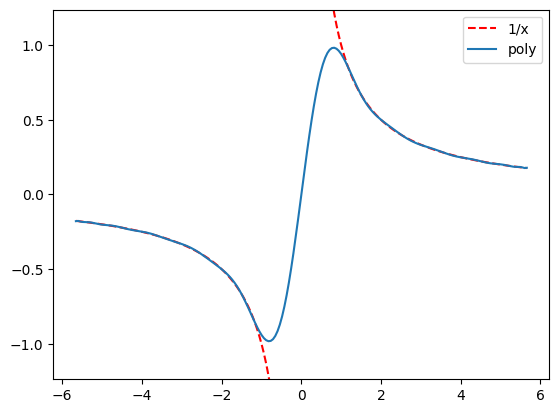

In [27]:
poly = A_half_inv.get_definition().coefficients.polynomial
xs = np.linspace(-A_half.normalization, A_half.normalization, 200)
plt.plot(xs[xs > 0], 1 / xs[xs > 0], "r--", label="1/x")
plt.plot(xs[xs < 0], 1 / xs[xs < 0], "r--")
plt.plot(xs, poly(xs), label="poly")
plt.legend()
_ = plt.ylim([-7 / A_half.normalization, 7 / A_half.normalization])

Let us now apply this inverse to the right hand side. Matrix-matrix and matrix-vector multiplication, as in numpy, is performed using the `@` operator.

In [28]:
solution = A_inv @ b

## 6. Verification and Simulation

Finally, we verify our results. We can compare the explicit matrix math using `.toarray()` with the library's internal quantum simulator using `.simulate()`. This (and other checks) are done automatically by calling `ut.verify`. We can also pass a reference value and tolerance to this function.

In [29]:
dim = 2**N - 1
A_reference = 2**N * (2 * np.eye(dim) - np.eye(dim, k=-1) - np.eye(dim, k=1))
reference = np.linalg.solve(A_reference, 2 ** (-N) * np.ones(dim))
ut.verify(A, A_reference)
ut.verify(solution, reference, atol=0.15)

In a more realistic scenario, we typically want to compute a quantity of interest, such as the $L^2$ norm of the solution function. This is approximated by $2^{-N/2}$ times the Euclidean norm of the solution vector

In [30]:
measured_qoi = solution.simulate_norm() * 2 ** (-N / 2)
print(f"Measured quantity of interest: {measured_qoi}")
print(f"Classically computed quantity of interest: {solution.compute_norm() * 2 ** (-N / 2)}")

Measured quantity of interest: 0.08825763494389514
Classically computed quantity of interest: 0.08825763494419324


Let's also compare it with the actual value, for which we compute a reference with a finer discretization.

In [31]:
N_reference = 12
dim = 2**N_reference - 1
reference = np.linalg.solve(
    2**N_reference * (2 * np.eye(dim) - np.eye(dim, k=-1) - np.eye(dim, k=1)), 2 ** (-N_reference) * np.ones(dim)
)
reference_qoi = np.linalg.norm(reference) * 2 ** (-N_reference / 2)
print(f"Reference quantity of interest: {reference_qoi}")

Reference quantity of interest: 0.09128709291789493


The error of roughly $0.003$ is within the specified tolerance.

## 7. Conclusion
Finally, to demonstrate the complexity going into constructing all these block encodings automatically, let us look under the hood of unitaria. By drawing the entire computational graph, including the definition of `PseudoNodes` by setting `verbose = True`, we see that unitaria reduces every operation to only a few basic types of graph nodes.

In [32]:
A_inv.tree(verbose=True)

╭─ Mul ───────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ UnsafeMul                                                                                                       │
│ ├── UnsafeMul                                                                                                   │
│ │   ├── Tensor                                                                                                  │
│ │   │   ├── UnsafeMul                                                                                           │
│ │   │   │   ├── child 0                                                                                         │
│ │   │   │   └── Identity{'subspace': Subspace("00###")}                                                         │
│ │   │   └── Identity{'subspace': Subspace("0")}                                                                 │
│ │   └── SubspaceCircuit                                                                                         │
│ └── Tensor                                                                                                      │
│     ├── UnsafeMul                                                                                               │
│     │   ├── Adjoint                                                                                             │
│     │   │   └── Identity{'subspace': Subspace("00###")}                                                         │
│     │   └── child 1                                                                                             │
│     └── Identity{'subspace': Subspace("0")}                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
├── Adjoint
│   └── ╭─ Pseudoinverse{'condition': np.float64(5.027339492125851), 'tolerance': 0.01, 'guaranteed': False} ─────╮
│       │ QSVT{'coefficients': array([ 0.   ,  1.156,  0.   , -0.243,  0.   ,  0.028,  0.   , -0.002,             │
│       │         0.   ,  0.   ,  0.   , -0.   ,  0.   ,  0.   ,  0.   , -0.   ,                                  │
│       │         0.   ,  0.   ,  0.   , -0.   ,  0.   ,  0.   ,  0.   , -0.   ,                                  │
│       │         0.   ,  0.   ]), 'format': 'chebyshev', 'normalization': np.float64(0.982802514076073)}         │
│       │ └── Adjoint                                                                                             │
│       │     └── child 0                                                                                         │
│       ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────╯
│       └── Scale{'scale': np.float64(2.8284271247461903), 'absolute': False}
│           └── ╭─ Mul ───────────────────────────────────────────────────────────────────────────────────────────╮
│               │ UnsafeMul                                                                                       │
│               │ ├── UnsafeMul                                                                                   │
│               │ │   ├── child 0                                                                                 │
│               │ │   └── Identity{'subspace': Subspace("###")}                                                   │
│               │ └── UnsafeMul                                                                                   │
│               │     ├── Adjoint                                                                                 │
│               │     │   └── Identity{'subspace': Subspace("0###")}                                              │
│               │     └── child 1                                                                                 │
│               ╰─────────────────────────────────────────────────────────────────